In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

# Load processed NAV history
nav = pd.read_csv("../DATA/PROCESSED/02_nav_history.csv")

nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [2]:
nav["date"] = pd.to_datetime(nav["date"])

In [3]:
nav = nav.sort_values(["amfi_code", "date"])

In [4]:
nav["daily_return"] = nav.groupby("amfi_code")["nav"].pct_change()

In [5]:
# Remove first missing return for each fund
returns = nav.dropna(subset=["daily_return"]).copy()

print("NAV records:", len(nav))
print("Return records:", len(returns))

NAV records: 46000
Return records: 45960


In [8]:
returns.head()

,amfi_code,date,nav,daily_return
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210
5,100016,2022-01-10,510.7136,-0.008639


In [10]:
# Available Funds 

fund_list = (nav[["amfi_code"]].drop_duplicates().sort_values("amfi_code"))

print(fund_list)

       amfi_code
0         100016
1150      100025
2300      100033
3450      101206
4600      101207
5750      101208
6900      102885
8050      102886
9200      102887
10350     118632
11500     118633
12650     118634
13800     118635
14950     118636
16100     119092
17250     119093
18400     119094
19550     119095
20700     119120
21850     119551
23000     119552
24150     119598
25300     119599
26450     120503
27600     120504
28750     120505
29900     120506
31050     120507
32200     120841
33350     120842
34500     120843
35650     120844
36800     125497
37950     125498
39100     148567
40250     148568
41400     148569
42550     149322
43700     149323
44850     149324


In [11]:
# Select one fund
selected_amfi = 100016

fund_data = returns[
    returns["amfi_code"] == selected_amfi
].copy()

# Historical daily return parameters
mean_daily_return = fund_data["daily_return"].mean()
std_daily_return = fund_data["daily_return"].std()

# Annualized parameters
annual_return = mean_daily_return * 252
annual_volatility = std_daily_return * np.sqrt(252)

# Latest NAV
latest_nav = fund_data.sort_values("date")["nav"].iloc[-1]

print("Selected AMFI Code:", selected_amfi)
print("Latest NAV:", round(latest_nav, 2))
print("Annualized Return:", round(annual_return * 100, 2), "%")
print("Annualized Volatility:", round(annual_volatility * 100, 2), "%")

Selected AMFI Code: 100016
Latest NAV: 583.61
Annualized Return: 3.57 %
Annualized Volatility: 14.55 %


In [13]:
# Monte Carlo parameters

years = 5
trading_days = 252
simulations = 1000

days = years * trading_days

# Random daily returns
np.random.seed(42)

random_returns = np.random.normal(
    loc=mean_daily_return,
    scale=std_daily_return,
    size=(days, simulations)
)

# Simulated NAV paths
nav_paths = np.zeros((days + 1, simulations))
nav_paths[0] = latest_nav

for day in range(1, days + 1):
    nav_paths[day] = (nav_paths[day - 1] * (1 + random_returns[day - 1]))

print("Simulation completed.")
print("Number of simulations:", simulations)
print("Projection period:", years, "years")
print("Trading days:", days)

Simulation completed.
Number of simulations: 1000
Projection period: 5 years
Trading days: 1260


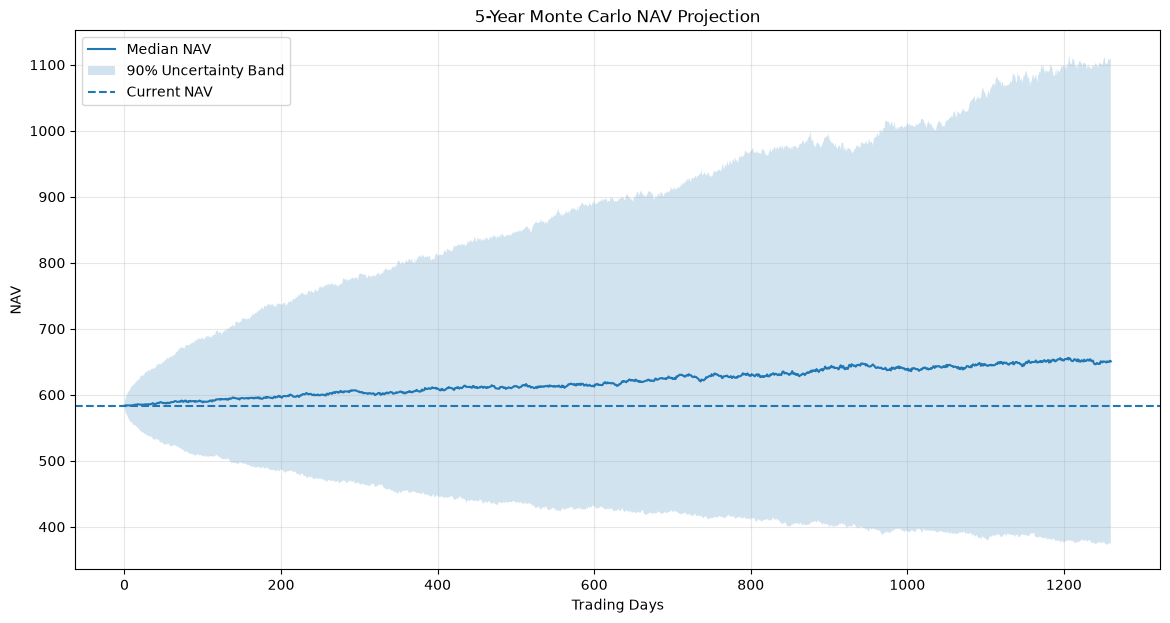

In [14]:
# Calculate percentiles for each day

median_nav = np.percentile(nav_paths, 50, axis=1)
lower_band = np.percentile(nav_paths, 5, axis=1)
upper_band = np.percentile(nav_paths, 95, axis=1)

days_axis = np.arange(days + 1)

# Plot Monte Carlo projection

plt.figure(figsize=(14, 7))

plt.plot(
    days_axis,
    median_nav,
    label="Median NAV"
)

plt.fill_between(
    days_axis,
    lower_band,
    upper_band,
    alpha=0.2,
    label="90% Uncertainty Band"
)

plt.axhline(
    latest_nav,
    linestyle="--",
    label="Current NAV"
)

plt.title("5-Year Monte Carlo NAV Projection")
plt.xlabel("Trading Days")
plt.ylabel("NAV")
plt.legend()
plt.grid(alpha=0.3)

plt.show()